In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
import os
# Save df_final as a .csv file
os.chdir(r'D:\sample_dataset')
df=pd.read_csv('augmented_dataset.csv', low_memory=False)

In [3]:
df.shape

(1504000, 22)

In [5]:
X = df.drop(columns=["Label"])  # Select all features except 'Label'
y = df["Label"]  # Select 'Label' as the target variable

In [6]:
X = X.to_numpy()  # Convert DataFrame to NumPy array
y = y.to_numpy()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold

# Define the fitness function for feature selection based on mutual information
def fitness_function(mask, X, y):
    selected_features = np.where(mask == 1)[0]
    if len(selected_features) == 0:
        return 0  # No features selected, so fitness is zero
    X_selected = X[:, selected_features]
    mi = mutual_info_classif(X_selected, y, discrete_features='auto')
    return np.sum(mi)  # Maximize the sum of mutual information

# Define the constraint violation function (if any)
def constraint_violation(mask):
    return 0  # No constraints in this case

# Initialize parameters
N = 20  # Population size
T = 100  # Maximum iterations
T_th = 0.5  # Temperature threshold
α = 0.1  # Seasonal activity factor
β = 0.5  # Reversal factor
γ = 0.1  # Learning rate
δ = 0.01  # Step size
ε = 0.1  # Social factor
λ = 10  # Penalty coefficient
η = 0.5  # Crossover coefficient
convergence_threshold = 1e-6  # Convergence threshold for fitness improvement
no_improvement_limit = 10  # Number of iterations to wait for improvement before stopping

# Initialize Stratified K-Fold (CV = 5)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_fitness_scores_IMOA = []  # Store cross-validation fitness scores
cv_selected_features_IMOA = []
cv_fitness_histories_IMOA = []
cv_iteration_times_IMOA=[]

start_time_cv = time.time()  # Start time for CV execution

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Processing Fold {fold + 1}...")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Initialize population
    d = X_train.shape[1]  # Feature dimensions
    P = np.random.randint(0, 2, (N, d))  # Binary mask for feature selection

    # Evaluate initial fitness
    fitness = np.array([fitness_function(mask, X_train, y_train) for mask in P])
    penalized_fitness = fitness - λ * np.array([constraint_violation(mask) for mask in P])

    # Track best fitness values for convergence analysis
    fitness_history = []
    iteration_times = []
    
    best_fitness = np.max(penalized_fitness)
    best_solution = P[np.argmax(penalized_fitness)]
    
    t = 0
    no_improvement_count = 0

    while t < T and no_improvement_count < no_improvement_limit:
        iteration_start = time.time()
        fitness_history.append(best_fitness)

        for i in range(N):
            # Seasonal Abundance
            α_t = α * np.sin(2 * np.pi * t / T)
            P[i] = np.clip(P[i] + α_t * np.random.uniform(-1, 1, d), 0, 1).astype(int)

            # Obstacle Avoidance
            if penalized_fitness[i] < np.mean(penalized_fitness):
                P[i] = np.clip(P[i] - β * np.random.uniform(-1, 1, d), 0, 1).astype(int)

            # Temperature Response
            if np.random.uniform(0, 1) > T_th:
                best_idx = np.argmax(penalized_fitness)
                P[i] = np.clip(P[i] + γ * (P[best_idx] - P[i]), 0, 1).astype(int)

            # Resource Utilization
            gradient = (fitness_function(P[i], X_train, y_train) + δ) - fitness_function(P[i], X_train, y_train) / δ
            P[i] = np.clip(P[i] + δ * gradient, 0, 1).astype(int)

            # Group Movement
            P[i] = np.clip(P[i] + ε * (np.mean(P, axis=0) - P[i]), 0, 1).astype(int)

            # Mating Behavior
            mate_idx = np.random.randint(N)
            P[i] = np.clip(η * P[i] + (1 - η) * P[mate_idx], 0, 1).astype(int)

        # Evaluate fitness of new positions
        fitness = np.array([fitness_function(mask, X_train, y_train) for mask in P])
        penalized_fitness = fitness - λ * np.array([constraint_violation(mask) for mask in P])

        # Update best solution
        current_best_fitness = np.max(penalized_fitness)
        if current_best_fitness > best_fitness + convergence_threshold:
            best_fitness = current_best_fitness
            best_solution = P[np.argmax(penalized_fitness)]
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        iteration_times.append(time.time() - iteration_start)
        t += 1

    # Store fold result
    cv_fitness_scores_IMOA.append(best_fitness)
 
    cv_fitness_histories_IMOA.append(fitness_history)
    cv_iteration_times_IMOA.append(np.mean(iteration_times))
total_runtime_cv_IMOA = time.time() - start_time_cv

Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...


In [48]:
cv_iteration_times_IMOA

[133.919631729126,
 161.27669975280762,
 110.75659080505372,
 117.53314727783203,
 161.587719039917]

In [49]:
cv_fitness_scores_IMOA 

[1.3115243077057166,
 1.2970482576509574,
 1.294276144365136,
 1.34121314671569,
 1.316267333556994]

In [53]:
cv_fitness_histories_IMOA

[[1.119755097337496,
  1.1490789919894797,
  1.1842155859915613,
  1.2092510900661415,
  1.176739347265463,
  1.1791965497289725,
  1.2140022113316522,
  1.219600146890246,
  1.2113551875394353,
  1.2294702672183875,
  1.230282407003207,
  1.2528817864279165,
  1.2956235763103847,
  1.2807750340991981,
  1.2898229288914842,
  1.2967202027829512,
  1.3015389239195985,
  1.2941395088855385,
  1.3002548751400524,
  1.3092347353483342,
  1.3227728485934651,
  1.3179311843336334,
  1.3102326765337586,
  1.2975021463769816,
  1.3044687419037457,
  1.3096536094937121,
  1.297688844711404,
  1.2987373353221792,
  1.3063616678609313,
  1.3107702143886968,
  1.3223936354512025,
  1.3256330643127134,
  1.3337337156318814,
  1.3279676675188097,
  1.3373437985065597,
  1.3365793036321705,
  1.3266406022980048,
  1.327564301556167,
  1.3321330909789244,
  1.3420375140130203,
  1.3357597188375,
  1.3491450493245543,
  1.3263201160528635,
  1.3260630665986157,
  1.3481011156301497,
  1.338185711292538

In [50]:
import numpy as np

# Assuming cv_iteration_times_GA and cv_fitness_scores_GA are NumPy arrays
mean_iteration_time = np.mean(cv_iteration_times_IMOA)
std_iteration_time = np.std(cv_iteration_times_IMOA)

mean_fitness_score = np.mean(cv_fitness_scores_IMOA)
std_fitness_score = np.std(cv_fitness_scores_IMOA)

print(f"Average time per iteration (across all folds)(IMOA): {mean_iteration_time:.4f} ± {std_iteration_time:.4f} sec")
print(f"Average Best Fitness over {fold+1} folds(IMOA): {mean_fitness_score:.4f} ± {std_fitness_score:.4f}")

Average time per iteration (across all folds)(IMOA): 137.0148 ± 21.3123 sec
Average Best Fitness over 5 folds(IMOA): 1.3121 ± 0.0168


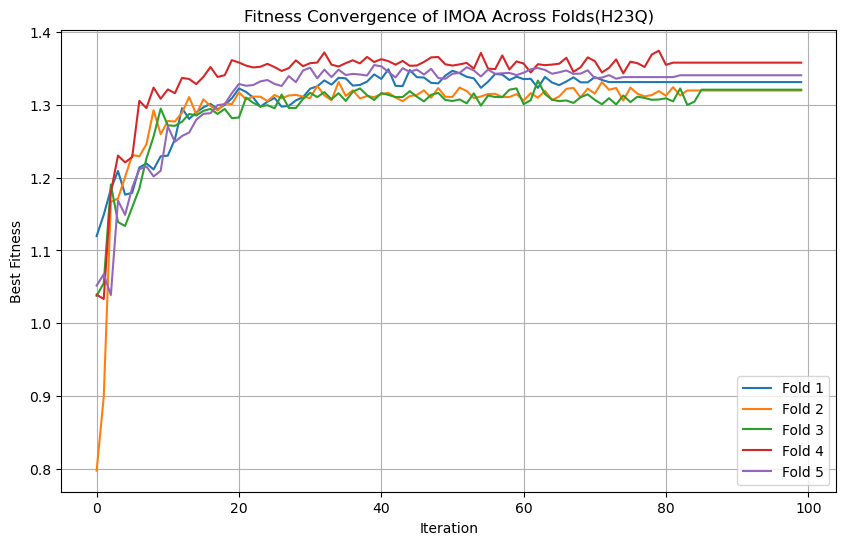

In [51]:



# Plot average fitness convergence across folds
plt.figure(figsize=(10, 6))
for i, history in enumerate(cv_fitness_histories_IMOA):
    plt.plot(history, label=f"Fold {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Fitness Convergence of IMOA Across Folds(H23Q)")
plt.legend()
plt.grid(True)
plt.savefig("IMOA_fitness_peerj_revision1_H23Q.pdf",format='pdf')
plt.show()

In [64]:
import numpy as np

# Assuming cv_iteration_times_GA and cv_fitness_scores_GA are NumPy arrays
mean_iteration_time = np.mean(cv_iteration_times_IMOA)
std_iteration_time = np.std(cv_iteration_times_IMOA)

mean_fitness_score = np.mean(cv_fitness_scores_IMOA)
std_fitness_score = np.std(cv_fitness_scores_IMOA)

print(f"Average time per iteration (across all folds)(IMOA): {mean_iteration_time:.4f} ± {std_iteration_time:.4f} sec")
print(f"Average Best Fitness over {fold+1} folds(IMOA): {mean_fitness_score:.4f} ± {std_fitness_score:.4f}")

Average time per iteration (across all folds)(IMOA): 137.0148 ± 21.3123 sec
Average Best Fitness over 5 folds(IMOA): 1.3121 ± 0.0168


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold

# PSO parameters
N = 20      # Number of particles
T = 100     # Max iterations
w = 0.7     # Inertia weight
c1 = 1.5    # Cognitive coefficient
c2 = 1.5    # Social coefficient
folds = 5   # Cross-validation folds

# Stratified 5-fold CV
kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
cv_fitness_scores_PSO = []
cv_selected_features_PSO = []
cv_fitness_histories_PSO = []
cv_iteration_times_PSO=[]
start_time_cv = time.time()

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\nProcessing Fold {fold + 1}...")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    d = X_train.shape[1]

    # Define fitness function for the current fold
    def fitness_function(mask):
        selected_features = np.where(mask == 1)[0]
        if len(selected_features) == 0:
            return 0
        X_selected = X_train[:, selected_features]
        mi = mutual_info_classif(X_selected, y_train, discrete_features='auto')
        return np.sum(mi)

    # Initialize population
    P = np.random.randint(0, 2, (N, d))
    V = np.random.uniform(-1, 1, (N, d))
    fitness = np.array([fitness_function(mask) for mask in P])
    p_best = P.copy()
    p_best_fitness = fitness.copy()
    g_best = P[np.argmax(fitness)]
    g_best_fitness = np.max(fitness)

    fitness_history = []
    iteration_times = []

    for t in range(T):
        iteration_start = time.time()

        for i in range(N):
            r1, r2 = np.random.rand(d), np.random.rand(d)
            V[i] = w * V[i] + c1 * r1 * (p_best[i] - P[i]) + c2 * r2 * (g_best - P[i])
            P[i] = np.clip(P[i] + V[i], 0, 1).astype(int)

            fitness[i] = fitness_function(P[i])
            if fitness[i] > p_best_fitness[i]:
                p_best[i] = P[i]
                p_best_fitness[i] = fitness[i]

        best_idx = np.argmax(p_best_fitness)
        if p_best_fitness[best_idx] > g_best_fitness:
            g_best = p_best[best_idx]
            g_best_fitness = p_best_fitness[best_idx]

        fitness_history.append(g_best_fitness)
        iteration_times.append(time.time() - iteration_start)

    # Store results for this fold
    cv_fitness_scores_PSO.append(g_best_fitness)
    cv_selected_features_PSO.append(np.where(g_best == 1)[0])
    cv_fitness_histories_PSO.append(fitness_history)
    cv_iteration_times_PSO.append(np.mean(iteration_times))

    #print(f"Best Fitness in Fold {fold + 1}: {g_best_fitness}")
    #print(f"Selected features: {np.where(g_best == 1)[0]}")
# Cross-validation summary
total_runtime_cv_PSO = time.time() - start_time_cv


Processing Fold 1...

Processing Fold 2...

Processing Fold 3...

Processing Fold 4...

Processing Fold 5...


In [19]:
import numpy as np

# Assuming cv_iteration_times_GA and cv_fitness_scores_GA are NumPy arrays
mean_iteration_time = np.mean(cv_iteration_times_PSO)
std_iteration_time = np.std(cv_iteration_times_PSO)

mean_fitness_score = np.mean(cv_fitness_scores_PSO)
std_fitness_score = np.std(cv_fitness_scores_PSO)

print(f"Average time per iteration (across all folds)(PSO): {mean_iteration_time:.4f} ± {std_iteration_time:.4f} sec")
print(f"Average Best Fitness over {fold+1} folds(PSO): {mean_fitness_score:.4f} ± {std_fitness_score:.4f}")

Average time per iteration (across all folds)(PSO): 1188.7140 ± 183.7473 sec
Average Best Fitness over 5 folds(PSO): 1.4882 ± 0.0851


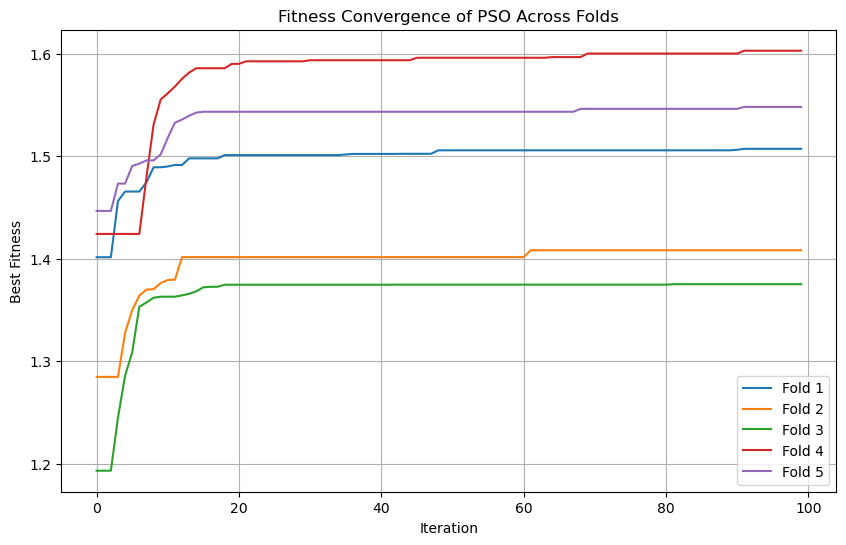

In [20]:
# Plot average fitness convergence across folds
plt.figure(figsize=(10, 6))
for i, history in enumerate(cv_fitness_histories_PSO):
    plt.plot(history, label=f"Fold {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Fitness Convergence of PSO Across Folds")
plt.legend()
plt.grid(True)
plt.savefig("PSO_convergence_peerj_revision1_H23Q.pdf",format="pdf")
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold

# GWO parameters
N = 20      # Number of wolves
T = 100     # Max iterations
folds = 5   # Cross-validation folds

# Stratified 5-fold CV
kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
cv_fitness_scores_GWO = []
cv_selected_features_GWO = []
cv_fitness_histories_GWO = []
cv_iteration_times_GWO = []

start_time_cv = time.time()

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\nProcessing Fold {fold + 1}...")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    d = X_train.shape[1]

    # Define fitness function with fallback when no features are selected
    def fitness_function(mask):
        selected_features = np.where(mask == 1)[0]
        if len(selected_features) == 0:
            return 1e-6  # Small positive value to avoid zero fitness
        X_selected = X_train[:, selected_features]
        mi = mutual_info_classif(X_selected, y_train, discrete_features='auto')
        return np.sum(mi)

    # Initialize wolves with at least one feature selected
    wolves = np.random.randint(0, 2, (N, d))
    for i in range(N):
        if np.sum(wolves[i]) == 0:
            wolves[i][np.random.randint(0, d)] = 1  # Ensure at least one feature is selected

    fitness = np.array([fitness_function(mask) for mask in wolves])

    # Identify alpha, beta, and delta wolves (best three solutions)
    sorted_indices = np.argsort(-fitness)
    alpha, beta, delta = wolves[sorted_indices[:3]]

    fitness_history = []
    iteration_times = []

    for t in range(T):
        iteration_start = time.time()
        
        a = 2 - 1.5 * (t / T)  # Slower decay to improve exploration

        for i in range(N):
            r1, r2 = np.random.rand(d), np.random.rand(d)
            A1, A2, A3 = 2 * a * r1 - a, 2 * a * r2 - a, 2 * a * np.random.rand(d) - a

            D_alpha = np.abs(A1 * alpha - wolves[i])
            D_beta = np.abs(A2 * beta - wolves[i])
            D_delta = np.abs(A3 * delta - wolves[i])

            wolves[i] = np.clip((alpha - D_alpha + beta - D_beta + delta - D_delta) / 3, 0, 1).astype(int)

            # Ensure at least one feature is selected
            if np.sum(wolves[i]) == 0:
                wolves[i][np.random.randint(0, d)] = 1

            fitness[i] = fitness_function(wolves[i])

        # Update alpha, beta, and delta
        sorted_indices = np.argsort(-fitness)
        alpha, beta, delta = wolves[sorted_indices[:3]]

        fitness_history.append(fitness[sorted_indices[0]])  # Store best fitness per iteration
        iteration_times.append(time.time() - iteration_start)

    # Store results for this fold
    cv_fitness_scores_GWO.append(fitness[sorted_indices[0]])
    cv_selected_features_GWO.append(np.where(alpha == 1)[0])
    cv_fitness_histories_GWO.append(fitness_history)
    cv_iteration_times_GWO.append(np.mean(iteration_times))
total_runtime_cv_GWO = time.time() - start_time_cv    


Processing Fold 1...

Processing Fold 2...

Processing Fold 3...

Processing Fold 4...

Processing Fold 5...


In [24]:
import numpy as np

# Assuming cv_iteration_times_GA and cv_fitness_scores_GA are NumPy arrays
mean_iteration_time = np.mean(cv_iteration_times_GWO)
std_iteration_time = np.std(cv_iteration_times_GWO)

mean_fitness_score = np.mean(cv_fitness_scores_GWO)
std_fitness_score = np.std(cv_fitness_scores_GWO)

print(f"Average time per iteration (across all folds)(GWO): {mean_iteration_time:.4f} ± {std_iteration_time:.4f} sec")
print(f"Average Best Fitness over {fold+1} folds(GWO): {mean_fitness_score:.4f} ± {std_fitness_score:.4f}")

Average time per iteration (across all folds)(GWO): 71.2276 ± 4.3994 sec
Average Best Fitness over 5 folds(GWO): 0.2478 ± 0.0786


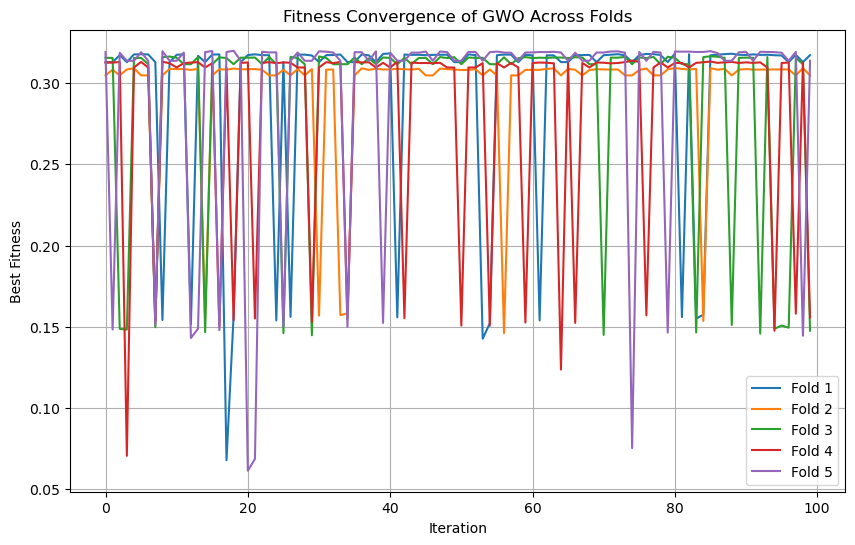

In [25]:
# Plot fitness convergence across folds
plt.figure(figsize=(10, 6))
for i, history in enumerate(cv_fitness_histories_GWO):
    plt.plot(history, label=f"Fold {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Fitness Convergence of GWO Across Folds")
plt.legend()
plt.grid(True)
plt.savefig("GWO_convergence_peerj_revision1_H23Q.pdf", format="pdf")
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold

# GA parameters
N = 20      # Population size (chromosomes)
T = 100     # Max generations
Pc = 0.8    # Crossover probability
Pm = 0.2    # Mutation probability
folds = 5   # Cross-validation folds

# Stratified 5-fold CV
kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
cv_fitness_scores_GA = []
cv_selected_features_GA = []
cv_fitness_histories_GA = []
cv_iteration_times_GA = []

start_time_cv = time.time()

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\nProcessing Fold {fold + 1}...")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    d = X_train.shape[1]

    # Define fitness function
    def fitness_function(mask):
        selected_features = np.where(mask == 1)[0]
        if len(selected_features) == 0:
            return 1e-6  # Small value to prevent zero fitness
        X_selected = X_train[:, selected_features]
        mi = mutual_info_classif(X_selected, y_train, discrete_features='auto')
        return np.sum(mi)

    # Initialize population with at least one feature selected
    population = np.random.randint(0, 2, (N, d))
    for i in range(N):
        if np.sum(population[i]) == 0:
            population[i][np.random.randint(0, d)] = 1  # Ensure at least one feature is selected

    fitness = np.array([fitness_function(mask) for mask in population])
    fitness_history = []
    iteration_times = []

    for t in range(T):
        iteration_start = time.time()

        # Selection (Tournament selection)
        parents = []
        for _ in range(N):
            idx1, idx2 = np.random.choice(N, 2, replace=False)
            winner = population[idx1] if fitness[idx1] > fitness[idx2] else population[idx2]
            parents.append(winner)
        parents = np.array(parents)

        # Crossover (Uniform crossover)
        offspring = parents.copy()
        for i in range(0, N, 2):
            if np.random.rand() < Pc:
                cross_points = np.random.randint(0, 2, d)
                offspring[i], offspring[i + 1] = (
                    np.where(cross_points, parents[i], parents[i + 1]),
                    np.where(cross_points, parents[i + 1], parents[i])
                )

        # Mutation (Bit flip mutation)
        for i in range(N):
            if np.random.rand() < Pm:
                mutation_point = np.random.randint(0, d)
                offspring[i][mutation_point] = 1 - offspring[i][mutation_point]

        # Ensure at least one feature is selected
        for i in range(N):
            if np.sum(offspring[i]) == 0:
                offspring[i][np.random.randint(0, d)] = 1

        # Compute fitness
        fitness = np.array([fitness_function(mask) for mask in offspring])
        population = offspring

        # Store best fitness
        best_idx = np.argmax(fitness)
        fitness_history.append(fitness[best_idx])
        iteration_times.append(time.time() - iteration_start)

    # Store results for this fold
    cv_fitness_scores_GA.append(fitness[best_idx])
    cv_selected_features_GA.append(np.where(population[best_idx] == 1)[0])
    cv_fitness_histories_GA.append(fitness_history)
    cv_iteration_times_GA.append(np.mean(iteration_times))


Processing Fold 1...

Processing Fold 2...

Processing Fold 3...

Processing Fold 4...

Processing Fold 5...


In [29]:
import numpy as np

# Assuming cv_iteration_times_GA and cv_fitness_scores_GA are NumPy arrays
mean_iteration_time = np.mean(cv_iteration_times_GA)
std_iteration_time = np.std(cv_iteration_times_GA)

mean_fitness_score = np.mean(cv_fitness_scores_GA)
std_fitness_score = np.std(cv_fitness_scores_GA)

print(f"Average time per iteration (across all folds)(GA): {mean_iteration_time:.4f} ± {std_iteration_time:.4f} sec")
print(f"Average Best Fitness over {fold+1} folds(GA): {mean_fitness_score:.4f} ± {std_fitness_score:.4f}")

Average time per iteration (across all folds)(GA): 1496.4866 ± 45.3354 sec
Average Best Fitness over 5 folds(GA): 1.6351 ± 0.0232


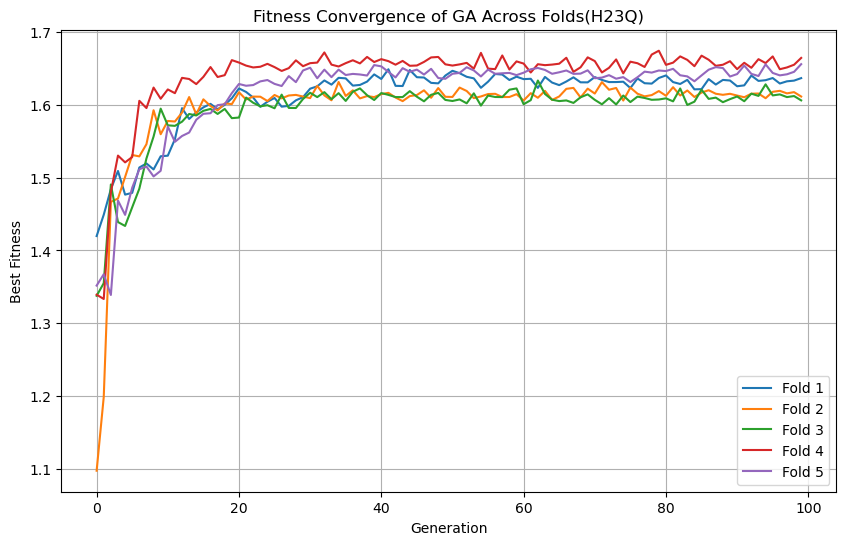

In [30]:
# Cross-validation summary

# Plot fitness convergence across folds
plt.figure(figsize=(10, 6))
for i, history in enumerate(cv_fitness_histories_GA):
    plt.plot(history, label=f"Fold {i+1}")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Fitness Convergence of GA Across Folds(H23Q)")
plt.legend()
plt.grid(True)
plt.savefig("GA_convergence_peerj_revision1_H23Q.pdf", format="pdf")
plt.show()

In [43]:

from scipy.stats import ttest_rel
print("\n=== Paired t-tests ===")
print("IMOA vs PSO:", ttest_rel(cv_iteration_times_IMOA, cv_iteration_times_PSO))
print("IMOA vs GWO:", ttest_rel(cv_iteration_times_IMOA, cv_iteration_times_GWO))
print("IMOA vs GA:", ttest_rel(cv_iteration_times_IMOA, cv_iteration_times_GA))


=== Paired t-tests ===
IMOA vs PSO: TtestResult(statistic=-11.373094163380863, pvalue=0.00034086148750609666, df=4)
IMOA vs GWO: TtestResult(statistic=6.015435970203863, pvalue=0.0038461383841040687, df=4)
IMOA vs GA: TtestResult(statistic=-50.28849023435138, pvalue=9.356918752796045e-07, df=4)


In [44]:
from scipy.stats import ttest_rel
print("\n=== Paired t-tests ===")
print("IMOA vs PSO:", ttest_rel(cv_fitness_scores_IMOA, cv_fitness_scores_PSO))
print("IMOA vs GWO:", ttest_rel(cv_fitness_scores_IMOA, cv_fitness_scores_GWO))
print("IMOA vs GA:", ttest_rel(cv_fitness_scores_IMOA, cv_fitness_scores_GA))


=== Paired t-tests ===
IMOA vs PSO: TtestResult(statistic=-5.134434717334658, pvalue=0.0068175152117500885, df=4)
IMOA vs GWO: TtestResult(statistic=25.392162472705778, pvalue=1.428483744735372e-05, df=4)
IMOA vs GA: TtestResult(statistic=-71.8726415964275, pvalue=2.245621420463906e-07, df=4)


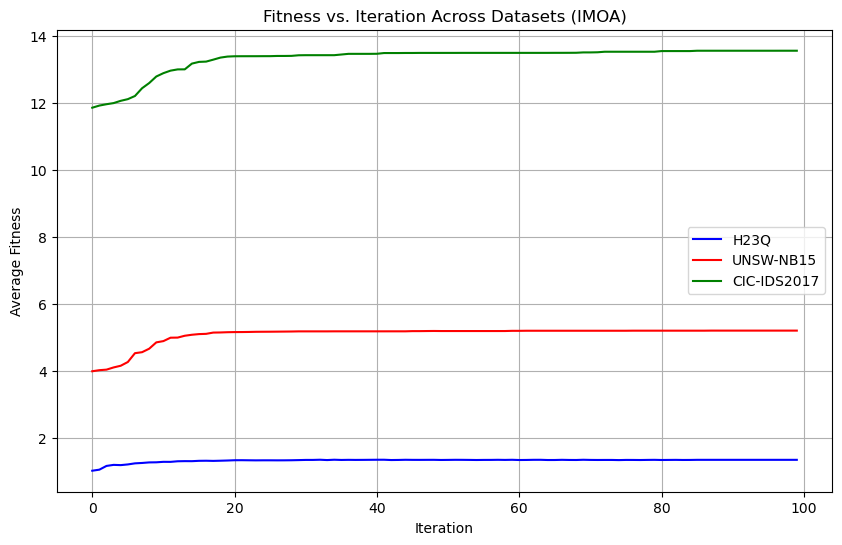

In [65]:


import numpy as np
import matplotlib.pyplot as plt


cv_fitness_histories_H23Q = cv_fitness_histories_IMOA 



# Compute average fitness across 5 folds for each dataset
mean_fitness_H23Q = np.mean(cv_fitness_histories_H23Q, axis=0)
mean_fitness_UNSW_NB15 = np.mean(cv_fitness_histories_UNSW_NB15, axis=0)
mean_fitness_CIC_IDS2017 = np.mean(cv_fitness_histories_CIC_IDS2017, axis=0)

# Plot fitness evolution
plt.figure(figsize=(10, 6))

plt.plot(mean_fitness_H23Q, label="H23Q", color='blue')
plt.plot(mean_fitness_UNSW_NB15, label="UNSW-NB15",  color='red')
plt.plot(mean_fitness_CIC_IDS2017, label="CIC-IDS2017",  color='green')

# Formatting the plot
plt.xlabel("Iteration")
plt.ylabel("Average Fitness")
plt.title("Fitness vs. Iteration Across Datasets (IMOA)")
plt.legend()
plt.grid(True)

# Save and display the plot
plt.savefig("Peerj_revision1_IMOA_Fitness_Convergence.pdf", format="pdf")
plt.show()

